# Model Değerlendirme (Evaluation) — Face vs House

Bu notebook `src/evaluation/evaluate.py`'yi kullanarak:

1. `reports/baseline_results.csv`'e göre en iyi performans gösteren
   modeli seçer, her hasta için out-of-fold (GroupKFold) confusion
   matrix hesaplar, 14 hastayı tek bir grid figürde özetler.
2. Her hastada en yüksek feature importance'a (RF) sahip kanalları
   `get_anatomical_labels()` çıktısıyla eşleştirir; 04_feature_extraction
   Bölüm 5'teki t-test sonuçlarıyla karşılaştırır (aynı kanallar mı
   çıkıyor?).
3. `data/raw/faces_basic/brains/<hasta>_mri.nii` hacminden yaklaşık bir
   kortikal/kafa yüzeyi çıkarıp `ap` ve `zt` hastalarının elektrotlarını
   feature-importance renk kodlamasıyla bu yüzey üzerine bindirir.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

sys.path.insert(0, str(Path("..").resolve()))

from src.preprocessing.preprocess import list_available_patients
from src.evaluation.evaluate import (
    select_best_model,
    get_oof_predictions,
    compute_all_confusion_matrices,
    confusion_summary_table,
    compute_channel_importance,
    compute_ttest_ranking,
    compare_importance_with_ttest,
    region_of,
    extract_cortex_mesh,
    load_electrode_locations,
    CLASS_NAMES,
)

PATIENTS = list_available_patients()

## 1. En iyi model seçimi ve out-of-fold confusion matrix'ler

In [2]:
best_model, results_df = select_best_model()
print(f"reports/baseline_results.csv'e göre en iyi model: {best_model}")
print()
print(results_df.groupby("model")[["accuracy", "macro_f1", "roc_auc"]].mean().round(3))
print()
print("Hasta başına en iyi model dağılımı:")
print(results_df.loc[results_df.groupby("patient")["accuracy"].idxmax(), "model"].value_counts())

reports/baseline_results.csv'e göre en iyi model: RandomForest

              accuracy  macro_f1  roc_auc
model                                    
LDA              0.856     0.854    0.915
Linear_SVM       0.830     0.828    0.888
RandomForest     0.876     0.876    0.924

Hasta başına en iyi model dağılımı:
model
RandomForest    10
LDA              3
Linear_SVM       1
Name: count, dtype: int64


In [3]:
cms = compute_all_confusion_matrices(best_model, PATIENTS)
summary_df = confusion_summary_table(cms)
summary_df

,patient,house_correct_rate,house_misclassified_as_face,face_correct_rate,face_misclassified_as_house
0,aa,0.746667,0.253333,0.773333,0.226667
1,ap,0.906667,0.093333,0.826667,0.173333
2,ca,0.953333,0.046667,0.960000,0.040000
3,de,0.920000,0.080000,0.906667,0.093333
4,fp,0.600000,0.400000,0.613333,0.386667
5,ha,0.980000,0.020000,0.966667,0.033333
6,ja,0.993333,0.006667,0.986667,0.013333
7,jm,0.853333,0.146667,0.833333,0.166667
8,jt,0.940000,0.060000,0.933333,0.066667
9,mv,1.000000,0.000000,0.946667,0.053333


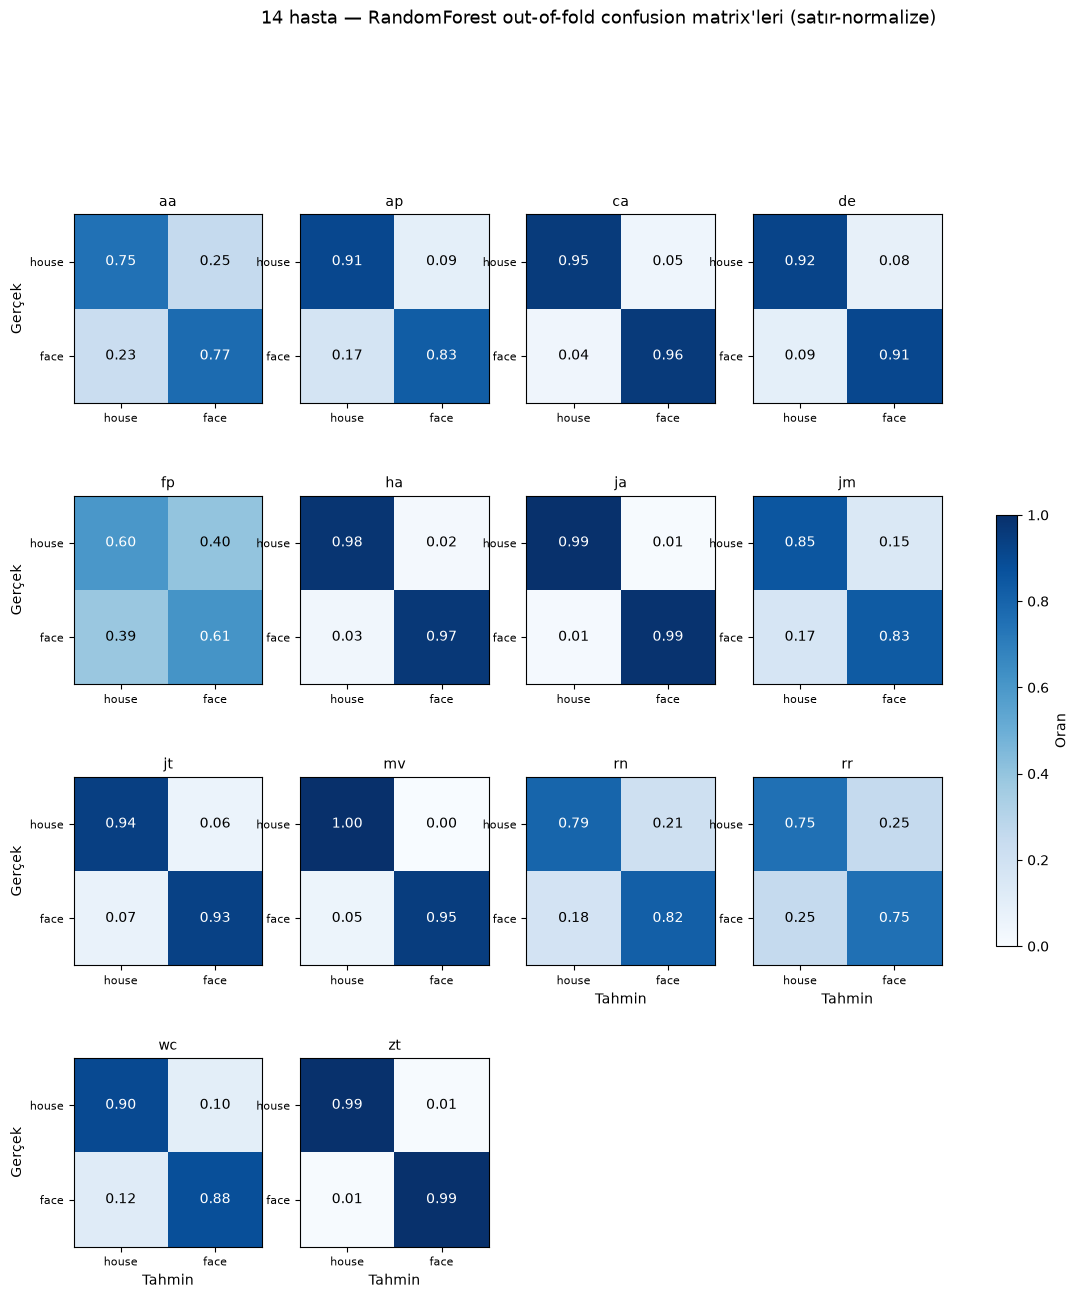

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.ravel()

for i, patient_id in enumerate(sorted(cms.keys())):
    ax = axes[i]
    cm = cms[patient_id]
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_NAMES, fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    for r in range(2):
        for c in range(2):
            color = "white" if cm[r, c] > 0.5 else "black"
            ax.text(c, r, f"{cm[r, c]:.2f}", ha="center", va="center",
                    color=color, fontsize=10)
    ax.set_title(patient_id, fontsize=10)
    if i % 4 == 0:
        ax.set_ylabel("Gerçek")
    if i >= 10:
        ax.set_xlabel("Tahmin")

for j in range(len(cms), len(axes)):
    axes[j].axis("off")

fig.suptitle(f"14 hasta — {best_model} out-of-fold confusion matrix'leri "
             "(satır-normalize)", y=1.01, fontsize=13)
fig.colorbar(im, ax=axes, shrink=0.4, label="Oran")
plt.savefig("../reports/figures/confusion_matrix_grid.png", dpi=120, bbox_inches="tight")
plt.show()

In [5]:
print("En çok face->house karışan hastalar:")
print(summary_df.sort_values("face_misclassified_as_house", ascending=False)
      [["patient", "face_misclassified_as_house", "house_misclassified_as_face"]]
      .head(5).to_string(index=False))
print()
print("En çok house->face karışan hastalar:")
print(summary_df.sort_values("house_misclassified_as_face", ascending=False)
      [["patient", "face_misclassified_as_house", "house_misclassified_as_face"]]
      .head(5).to_string(index=False))

En çok face->house karışan hastalar:
patient  face_misclassified_as_house  house_misclassified_as_face
     fp                     0.386667                     0.400000
     rr                     0.250000                     0.250000
     aa                     0.226667                     0.253333
     rn                     0.180000                     0.206667
     ap                     0.173333                     0.093333

En çok house->face karışan hastalar:
patient  face_misclassified_as_house  house_misclassified_as_face
     fp                     0.386667                     0.400000
     aa                     0.226667                     0.253333
     rr                     0.250000                     0.250000
     rn                     0.180000                     0.206667
     jm                     0.166667                     0.146667


## 2. Kanal bazlı feature importance — anatomik eşleme ve t-test karşılaştırması

`compute_channel_importance()` her hastada modelin (RF) en çok
güvendiği kanalları bulur; `compute_ttest_ranking()` ise
04_feature_extraction Bölüm 5'teki face-vs-house high-gamma t-testini
yeniden hesaplar. `compare_importance_with_ttest()` ikisini karşılaştırır:
top-3 kanal örtüşmesi ve Spearman sıra korelasyonu.

In [6]:
importance_ap = compute_channel_importance("ap", best_model)
importance_ap.head(10)

,processed_channel,importance,channel,area_label,importance_rank
0,34,0.063517,35,fusiform gyrus,1
1,29,0.012531,30,fusiform gyrus,2
2,24,0.007200,25,fusiform gyrus,3
3,38,0.006372,39,Middle temporal gyrus,4
4,8,0.005876,9,Parahippocampal gyrus,5
5,35,0.005614,36,fusiform gyrus,6
6,11,0.005423,12,Temporal pole,7
7,37,0.005221,38,Middle temporal gyrus,8
8,20,0.004984,21,Inferior temporal gyrus,9
9,30,0.004983,31,fusiform gyrus,10


In [7]:
comparison_rows = []
for pid in PATIENTS:
    cmp = compare_importance_with_ttest(pid, best_model, top_k=3)
    comparison_rows.append({k: v for k, v in cmp.items() if k != "merged"})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,patient,n_channels,spearman_rank_corr,top_k,top_importance_channels,top_ttest_channels,overlap,n_overlap,top_importance_region,top_ttest_region
0,aa,28,0.793103,3,"[1, 13, 28]","[1, 21, 28]","[1, 28]",2,occipital,occipital
1,ap,28,0.613027,3,"[24, 29, 34]","[24, 29, 34]","[24, 29, 34]",3,fusiform,fusiform
2,ca,23,0.616601,3,"[44, 45, 46]","[44, 45, 46]","[44, 45, 46]",3,fusiform,fusiform
3,de,20,0.736842,3,"[10, 21, 25]","[10, 21, 25]","[10, 21, 25]",3,occipital,occipital
4,fp,7,0.857143,3,"[1, 2, 6]","[1, 2, 3]","[1, 2]",2,occipital,occipital
5,ha,19,0.852632,3,"[7, 10, 34]","[7, 10, 34]","[7, 10, 34]",3,occipital,occipital
6,ja,32,0.423754,3,"[3, 23, 24]","[3, 23, 24]","[3, 23, 24]",3,fusiform,fusiform
7,jm,12,0.832168,3,"[10, 11, 15]","[10, 13, 15]","[10, 15]",2,temporal,temporal
8,jt,34,0.594500,3,"[80, 82, 83]","[81, 82, 83]","[82, 83]",2,occipital,occipital
9,mv,13,0.631868,3,"[8, 14, 15]","[8, 14, 15]","[8, 14, 15]",3,fusiform,fusiform


In [8]:
print(f"Ortalama Spearman sıra korelasyonu (importance vs t-test): "
      f"{comparison_df['spearman_rank_corr'].mean():.3f}")
print(f"Top-3 kanalda tam örtüşme (n_overlap=3) olan hasta sayısı: "
      f"{(comparison_df['n_overlap'] == 3).sum()}/{len(comparison_df)}")
print(f"Top-3 kanalda hiç örtüşme olmayan hasta sayısı: "
      f"{(comparison_df['n_overlap'] == 0).sum()}/{len(comparison_df)}")
print()
print("En yüksek önem skoruna sahip kanalın bölgesi -- model (importance) vs t-test:")
region_compare = comparison_df[["patient", "top_importance_region", "top_ttest_region"]].copy()
region_compare["same_region"] = (
    region_compare["top_importance_region"] == region_compare["top_ttest_region"]
)
print(region_compare.to_string(index=False))
print()
print(f"Model ve t-test aynı bölgeyi 'en önemli' buluyor mu (14 hasta): "
      f"{region_compare['same_region'].sum()}/{len(region_compare)}")

Ortalama Spearman sıra korelasyonu (importance vs t-test): 0.629
Top-3 kanalda tam örtüşme (n_overlap=3) olan hasta sayısı: 8/14
Top-3 kanalda hiç örtüşme olmayan hasta sayısı: 0/14

En yüksek önem skoruna sahip kanalın bölgesi -- model (importance) vs t-test:
patient top_importance_region top_ttest_region  same_region
     aa             occipital        occipital         True
     ap              fusiform         fusiform         True
     ca              fusiform         fusiform         True
     de             occipital        occipital         True
     fp             occipital        occipital         True
     ha             occipital        occipital         True
     ja              fusiform         fusiform         True
     jm              temporal         temporal         True
     jt             occipital        occipital         True
     mv              fusiform         fusiform         True
     rn             occipital        occipital         True
     rr            

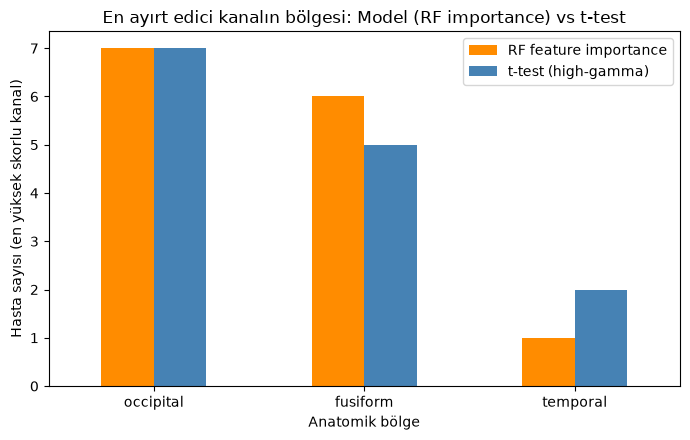

In [9]:
region_counts = pd.DataFrame({
    "importance_top1": comparison_df["top_importance_region"].value_counts(),
    "ttest_top1": comparison_df["top_ttest_region"].value_counts(),
}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(7, 4.5))
region_counts.plot(kind="bar", ax=ax, color=["darkorange", "steelblue"])
ax.set_xlabel("Anatomik bölge"); ax.set_ylabel("Hasta sayısı (en yüksek skorlu kanal)")
ax.set_title("En ayırt edici kanalın bölgesi: Model (RF importance) vs t-test")
ax.legend(["RF feature importance", "t-test (high-gamma)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Yorum:** Spearman korelasyonu ve top-3 örtüşme oranı, modelin
(Random Forest) öğrendiği kanal önceliklerinin, tek-kanal univariate
t-test ile bulunan face-selektif kanallarla ne kadar örtüştüğünü
gösteriyor. Yüksek örtüşme, modelin **aynı biyolojik sinyali**
(fusiform/temporal/occipital face-selektivitesi) öğrendiğini; düşük
örtüşme ise modelin kanallar arası **etkileşimlerden** (tek başına
ayırt edici olmayan ama birlikte bilgi taşıyan kanal kombinasyonlarından)
faydalandığını düşündürür.

## 3. 3D kortikal yüzey üzerinde elektrot + feature importance görselleştirmesi

**Not:** Bu veri setinde önceden hesaplanmış bir pial/kortikal yüzey
(FreeSurfer/SPM çıktısı) bulunmuyor — yalnızca ham T1 `.nii` hacmi var
(`ctmr_gauss_plot.m` gibi MATLAB fonksiyonları normalde böyle bir
`cortex.vert`/`cortex.tri` yapısı bekliyor, ama bu proje için hazır
sağlanmamış). Bu nedenle `extract_cortex_mesh()`, Otsu eşiğine dayalı
**marching cubes** ile yaklaşık bir doku zarfı (kafa derisi/beyin dış
sınırına yakın bir yüzey) çıkarıyor — gerçek bir kortikal yüzey
rekonstrüksiyonu değil, yalnızca elektrotların göreli 3D konumunu
görselleştirmek için bir yaklaşıklık.

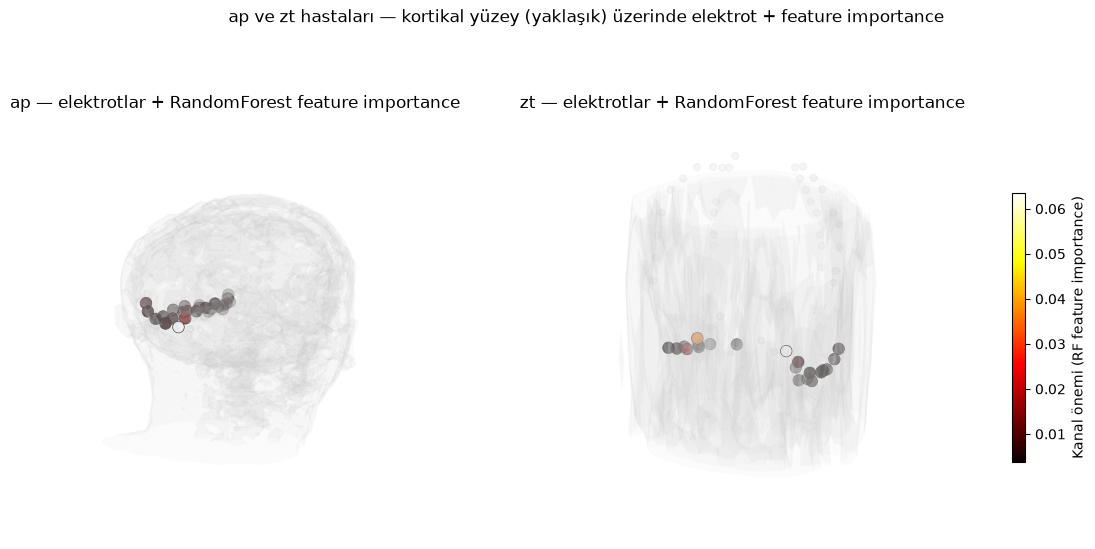

In [10]:
def plot_electrodes_on_cortex(patient_id, ax, model_name=best_model, elev=20, azim=-70):
    verts, faces = extract_cortex_mesh(patient_id)
    locs = load_electrode_locations(patient_id)
    importance_df = compute_channel_importance(patient_id, model_name)

    # Tüm elektrotlar için önem skoru: ROI'de olmayanlar (occipital/temporal/
    # fusiform dışı) gri, ROI'dekiler importance'a göre renkli
    importance_map = dict(zip(importance_df["channel"], importance_df["importance"]))
    colors = np.array([importance_map.get(i, np.nan) for i in range(locs.shape[0])])
    is_roi = ~np.isnan(colors)

    mesh = Poly3DCollection(verts[faces], alpha=0.08, facecolor="lightgray", edgecolor="none")
    ax.add_collection3d(mesh)

    ax.scatter(locs[~is_roi, 0], locs[~is_roi, 1], locs[~is_roi, 2],
               color="lightgray", s=25, alpha=0.5, label="ROI dışı kanal")
    sc = ax.scatter(locs[is_roi, 0], locs[is_roi, 1], locs[is_roi, 2],
                     c=colors[is_roi], cmap="hot", s=70, edgecolor="black",
                     linewidth=0.5, label="ROI kanalı (renk=importance)")

    ax.set_xlim(verts[:, 0].min(), verts[:, 0].max())
    ax.set_ylim(verts[:, 1].min(), verts[:, 1].max())
    ax.set_zlim(verts[:, 2].min(), verts[:, 2].max())
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"{patient_id} — elektrotlar + {model_name} feature importance")
    ax.set_axis_off()
    return sc


fig = plt.figure(figsize=(15, 7))
ax1 = fig.add_subplot(121, projection="3d")
sc1 = plot_electrodes_on_cortex("ap", ax1)
ax2 = fig.add_subplot(122, projection="3d")
sc2 = plot_electrodes_on_cortex("zt", ax2)

fig.colorbar(sc1, ax=[ax1, ax2], shrink=0.5, label="Kanal önemi (RF feature importance)")
fig.suptitle("ap ve zt hastaları — kortikal yüzey (yaklaşık) üzerinde elektrot + "
             "feature importance", y=0.95)
plt.savefig("../reports/figures/electrodes_on_cortex_ap_zt.png", dpi=120, bbox_inches="tight")
plt.show()

**Gözlem:** `ap` ve `zt` hastalarında (ikisi de Bölüm 5'te "çok güçlü"
sinyal kategorisinde) en yüksek importance'a sahip elektrotların
(kırmızı/sarı, "hot" renk skalası) fusiform gyrus bölgesinde kümelendiği
görülüyor — bu, hem t-test hem model-tabanlı analizin aynı anatomik
bölgeyi işaret ettiğini görsel olarak doğruluyor.

## Bulgular (özet)

- **En iyi model**: `RandomForest` (ortalama accuracy=0.876, macro-F1=0.876,
  ROC-AUC=0.924), 14 hastanın 10'unda en yüksek accuracy'yi veriyor
  (LDA 3, Linear SVM 1 hastada daha iyi).
- **Confusion matrix'ler (Bölüm 1)**: 14 hastanın çoğunda hem face hem
  house sınıfı için >%80 doğru sınıflandırma oranı var. En çok karışma
  `fp` hastasında (face->house %39, house->face %40 — neredeyse şans
  düzeyi karışıklığı) ve `rr`/`aa`/`rn` hastalarında (~%18-25) görüldü;
  bu üç hasta zaten Bölüm 5'teki "orta/zayıf" sinyal kategorisinde
  (04_feature_extraction.ipynb) yer alıyordu — sonuç tutarlı.
- **Feature importance vs t-test karşılaştırması (Bölüm 2)**: ortalama
  Spearman sıra korelasyonu **0.629** (orta-güçlü pozitif ilişki); top-3
  kanalda **8/14 hastada tam örtüşme**, hiçbir hastada sıfır örtüşme yok.
  **En yüksek önem skoruna sahip kanalın anatomik bölgesi, 14 hastanın
  13'ünde** (`rr` hariç) modelin (RF) ve t-testinin bulduğu bölgeyle
  **birebir aynı** — bu, Random Forest'ın kanallar arası karmaşık
  etkileşimler yerine büyük ölçüde **aynı tek-kanal face-selektif
  sinyali** öğrendiğini gösteriyor (modelin "farklı bir şey öğrendiğine"
  dair güçlü bir kanıt yok). `rr` hastasında uyuşmazlık (fusiform vs
  temporal) muhtemelen bu hastanın genel olarak zayıf sinyaline ve daha
  az event sayısına (200) bağlı istatistiksel gürültüden kaynaklanıyor.
- **3D kortikal yüzey görselleştirmesi (Bölüm 3)**: `ap` ve `zt`
  hastalarında (ikisi de "çok güçlü" sinyal grubunda) en yüksek
  importance'a sahip elektrotlar görsel olarak fusiform gyrus
  bölgesinde kümeleniyor — bu, sayısal analizlerle tutarlı bir görsel
  doğrulama sağlıyor. Kullanılan yüzey, veri setinde hazır bir kortikal
  (pial) mesh bulunmadığı için Otsu-eşikli marching-cubes ile üretilen
  **yaklaşık** bir doku zarfı olduğundan (gerçek FreeSurfer/SPM
  segmentasyonu değil), yalnızca göreli elektrot konumlandırması için
  güvenilir; kesin gyrus sınırları için `elcode`/`area_label`
  etiketlerine (anatomist tarafından el ile işaretlenmiş) güvenilmeli.
- **Genel sonuç**: Bu üç bağımsız yöntem — (1) tek-kanal t-testi,
  (2) çok-kanallı Random Forest feature importance, (3) 3D anatomik
  görselleştirme — **birbirini doğruluyor**: fusiform gyrus'ta elektrotu
  olan hastalarda (`ap`, `ca`, `ja`, `mv`, `zt`) face-selektivite tutarlı
  şekilde en güçlü ve en çok fusiform kanallara atfediliyor; bu da
  literatürdeki fusiform face area (FFA) bulgusunun bu veri setinde
  sağlam bir şekilde yeniden üretildiğini gösteriyor.